# Analysing the Black Scholes Pricing Model and Monte Carlo Simulations

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
import datetime

In [4]:
# Use our previously defined function to calculate the value of European Options via Black Scholes Equation

# Define d1, d2, n(x)
def d1(S,K,r,q,sigma,T,t):
    d1=(np.log(S/K)+((r-q+((sigma**2)/2))*(T-t)))/(sigma*np.sqrt((T-t)))
    return d1
def d2(S,K,r,q,sigma,T,t):
    d2=(np.log(S/K)+(r-q-((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))    
    return d2
def n(x):
    ans=np.exp(-(x**2)/2)/(np.sqrt(2*np.pi))   
    return ans
# Define Option Values for the 4 types of options
def Value_EC(S,K,r,q,sigma,T,t):
    OVEC= (S*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t))))-(K*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))
    return OVEC
def Value_EP(S,K,r,q,sigma,T,t):
    OVEP= -(S*(stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-q*(T-t))))+(K*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))
    return OVEP

In [5]:
# Using our work on Monte Carlo Simulations to slightly adapt it into a function

def Monte_Carlo_EC(S,K,r,q,sigma,T,t,I):
    # Creating our 2xI matrix of zeros
    data = np.zeros((2, I))
    # Creating our 1xI matrix of normally distributed random numbers
    np.random.seed(0)
    z = np.random.normal(0, 1, [1, I])
    # Calculating value of asset at expiry
    ST = S*np.exp((T-t)*(r - 0.5*sigma**2)+sigma*np.sqrt(T-t)*z)
    # Subtracting each value by the Strike Price and entering these into the bottom row of our 2xI matrix
    data[-1] = ST - K
    # Take the maximum of each column (either S-K or 0) and form an array from these
    maxi = np.amax(data, axis=0)
    # Sum the maximums and divide by the number of iterations
    average = np.sum(np.amax(data, axis=0))/float(I)
    # Multiply this by exp(-r(T-t)) to take account of the rate-free interest rate
    final=np.exp(-r*(T-t))*average
    # Calculations to find the Standard Error
    SE = (np.sqrt((np.sum((maxi - average)**2)) / (I-1)))/np.sqrt(I)
    return final,SE

def Monte_Carlo_EP(S,K,r,q,sigma,T,t,I):
    # Creating our 2xI matrix of zeros
    data2 = np.zeros((2, I))
    # Creating our 1xI matrix of normally distributed random numbers
    np.random.seed(0)
    z = np.random.normal(0, 1, [1, I])
    # Calculating value of asset at expiry
    ST = S*np.exp((T-t)*(r - 0.5*sigma**2)+sigma*np.sqrt(T-t)*z)
    # Subtracting each value by the Strike Price and entering these into the bottom row of our 2xI matrix
    data2[-1] = K - ST
    # Take the maximum of each column (either S-K or 0) and form an array from these
    maxi2 = np.amax(data2, axis=0)
    # Sum the maximums and divide by the number of iterations
    average2 = np.sum(np.amax(data2, axis=0))/float(I)
    # Multiply this by exp(-r(T-t)) to take account of the rate-free interest rate
    final2=np.exp(-r*(T-t))*average2
    return final2    

In [6]:
S = 200        #Underlying asset price
K = 180        #Strike Price
r = 0.05       #Rate free interest rate
q = 0          #Continuous Dividend Yield
sigma = 0.3    #Volatility
T = 1          #Time to expiry from start of contract
t = 0.5        #Current time
N = 10         #Number of timesteps
I = 10000000

In [7]:
Value_EC(200,180,0.05,0,0.3,1,0.5)

30.971932232886616

In [8]:
Monte_Carlo_EC(200,180,0.05,0,0.3,1,0.5,10000000)[0]

30.978185413930003

In [9]:
Value_EP(200,180,0.05,0,0.3,1,0.5)

6.527716397986474

In [10]:
Monte_Carlo_EP(200,180,0.05,0,0.3,1,0.5,10000000)

6.523492266620085

<ipython-input-5-422e54e67fd5>:20: RuntimeWarning: invalid value encountered in scalar divide
  SE = (np.sqrt((np.sum((maxi - average)**2)) / (I-1)))/np.sqrt(I)


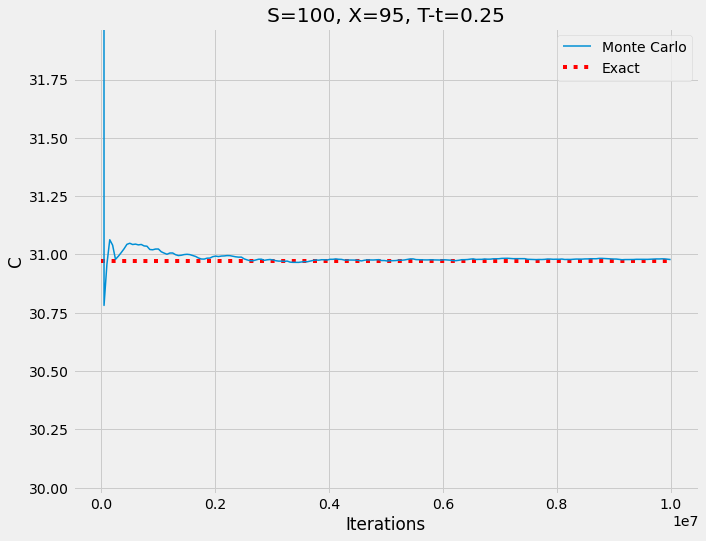

In [11]:
# Let us see how the number of iterations affect how close the Monte Carlo simulation is to the Black-Scholes value 

arr=[]
for i in range (1, 10000000, 50000):
    arr.append(Monte_Carlo_EC(200,180,0.05,0,0.3,1,0.5,i)[0])
index = np.linspace(1, 10000000, 200)
plt.figure(figsize=(10,8))
plt.hlines(Value_EC(200,180,0.05,0,0.3,1,0.5),xmin=0,xmax= 10000000,linestyle='dotted',colors='red',label = 'Exact')
plt.plot(index, arr ,lw = 1.5, label = 'Monte Carlo')
plt.title('S=100, X=95, T-t=0.25')
plt.xlabel('Iterations')
plt.ylabel('C')
plt.ylim(Value_EC(200,180,0.05,0,0.3,1,0.5)-1,Value_EC(200,180,0.05,0,0.3,1,0.5)+1)
plt.legend()
plt.show()

Now we will use real data from the European Call Options of ASML Holding NV to compare the effectiveness of both pricing models.

Firstly, we can easily access the data from [Yahoo Finance](https://finance.yahoo.com/quote/ASML/options/?date=1768521600) and [Euronext](https://live.euronext.com/en/product/stock-options/AS9-DAMS). We can find the price of an option at this current time and rate free interest rate and the strike price and time to expiry of the option. <br>
Now using our implied volatility calculator, we can make an estimate of the volatility.<br>
Then we will use this volatility value to calculate our calculations for the option value using Black-Scholes and Monte Carlo Simulations. Then we can compare these 2 values and the actual value of the option to make a comparative analysis with a plot to aid in visualising this.

In [27]:
# Initial Derivative Parameters
S = 769.54
K = 750
r = 0.046
q = 0
T = ((datetime.date(2025,3,17)-datetime.date(2025,1,21)).days+1)/365
t = 0
EC_Value = 100
epsilon = 10**(-8)

In [14]:
# Vega and Implied Volatility Function we made in an earlier notebook

def Vega_EC(S,K,r,q,sigma,T,t):
    VEC = S*(np.sqrt(T-t))*(n(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t)))
    return VEC
def ImpVol_EC(S,K,r,q,T,t,EC,epsilon,iterations=1000):
    sigma = np.sqrt((2*np.pi)/T)*(EC/S)
    for i in range(iterations):
        difference = (Value_EC(S,K,r,q,sigma,T,t)) - EC
        if abs(difference) < epsilon:
            #print(f'Found on {i}th iteration')
            #print(f'Difference is equal to {difference}')
            #print()
            sigma = sigma*100
            #print(f'Volatility is {sigma}%')
            break
        sigma = sigma - ((difference)/(Vega_EC(S,K,r,q,sigma,T,t)))
    return sigma/100

In [15]:
# Finding implied volatility
sigma = ImpVol_EC(S,K,r,q,T,t,EC_Value,epsilon,iterations=1000)

In [16]:
# Using our Black-Scholes formula and running Monte Carlo Simulations
BS = Value_EC(S,K,r,q,sigma,T,t)
MC,SE = Monte_Carlo_EC(S,K,r,q,sigma,T,t,100000000)

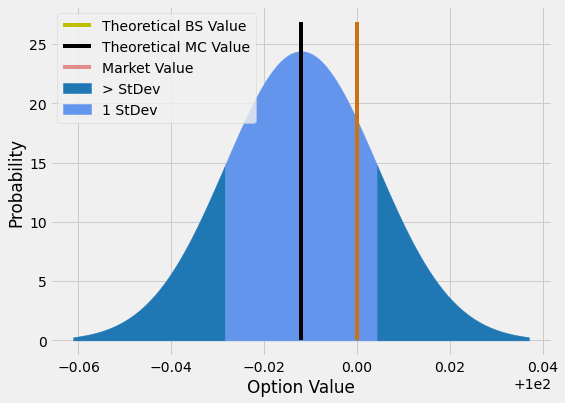

In [28]:
# Plotting to visualise option values
x1 = np.linspace(MC-3*SE, MC-1*SE, 100)
x2 = np.linspace(MC-1*SE, MC+1*SE, 100)
x3 = np.linspace(MC+1*SE, MC+3*SE, 100)

s1 = stats.norm.pdf(x1, MC, SE)
s2 = stats.norm.pdf(x2, MC, SE)
s3 = stats.norm.pdf(x3, MC, SE)

plt.figure(figsize=(8,6))
plt.fill_between(x1, s1, color='tab:blue',label='> StDev')
plt.fill_between(x2, s2, color='cornflowerblue',label='1 StDev')
plt.fill_between(x3, s3, color='tab:blue')
plt.plot([BS,BS],[0, max(s2)*1.1], 'y', label='Theoretical BS Value')
plt.plot([MC,MC],[0, max(s2)*1.1], 'k', label='Theoretical MC Value')
plt.plot([EC_Value,EC_Value],[0, max(s2)*1.1], 'tab:red', alpha=0.5, label='Market Value')
plt.ylabel("Probability")
plt.xlabel("Option Value")
plt.legend()
plt.show()

From all of this, we can see that the Monte Carlo Simulation is a very good numerical implementation algorithm paired with the Black-Scholes model to predict the value of an Option.